In [ ]:
# 시각화 글씨 깨짐 방지를 위한 폰트 설치 (실행 후, 런타임 다시 시작 뒤 2번 셀 실행)
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 45 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [ ]:
# 시각화 폰트 불러오기
import matplotlib.pyplot as plt

plt.rc('font', family='NanumBarunGothic')

In [ ]:
! pip install pmdarima

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 9.7 MB/s eta 0:00:00


In [1]:
from matplotlib import font_manager, rc
# 한글 폰트 설정
font_path = "C:/Windows/Fonts/malgun.ttf"  # 사용하고 있는 OS에 맞는 한글 폰트 경로로 수정해주세요.
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping
from pmdarima.arima import auto_arima
from tqdm import tqdm

In [4]:
# 데이터 로드
file_path = 'wind_power_by_weather.csv'

# 인코딩을 여러 가지로 시도
encodings = ['utf-8', 'euc-kr', 'latin1']

for encoding in encodings:
    try:
        df = pd.read_csv(file_path, encoding=encoding)
        print(f"File successfully read with {encoding} encoding.")
        break
    except UnicodeDecodeError:
        print(f"Failed to read file with {encoding} encoding.")

# 필요한 컬럼만 선택
df = df[['일시', '풍속(m/s)', '일사(MJ/m2)', '중하층운량(10분위)', '지면온도(°C)', '풍력전체']]
df['일시'] = pd.to_datetime(df['일시'])

# 데이터 정렬
df = df.sort_values(by='일시')

# 결측치 처리
df = df.fillna(0)

# 독립변수와 종속변수 설정
X = df[['풍속(m/s)', '일사(MJ/m2)', '중하층운량(10분위)', '지면온도(°C)']]
y = df['풍력전체']

# 데이터 스케일링
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

File successfully read with utf-8 encoding.


In [5]:
# 시계열 데이터를 LSTM/GRU 입력 형식에 맞게 변환
def create_sequences(X, y, time_steps=30):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:i + time_steps])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

time_steps = 30
X_seq, y_seq = create_sequences(X_scaled, y_scaled)

# 데이터셋 분할
split = int(len(X_seq) * 0.8)
X_train_seq, X_test_seq = X_seq[:split], X_seq[split:]
y_train_seq, y_test_seq = y_seq[:split], y_seq[split:]

X_train_rf, X_test_rf = X_scaled[:split], X_scaled[split:]
y_train_rf, y_test_rf = y_scaled[:split], y_scaled[split:]

In [6]:
# 조기 종료 콜백
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# LSTM 모델 정의
def create_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(50, activation='relu', input_shape=input_shape))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

# GRU 모델 정의
def create_gru_model(input_shape):
    model = Sequential()
    model.add(GRU(50, activation='relu', input_shape=input_shape))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

In [7]:
# LSTM 모델 학습 및 예측
lstm_model = create_lstm_model((X_train_seq.shape[1], X_train_seq.shape[2]))
gru_model = create_gru_model((X_train_seq.shape[1], X_train_seq.shape[2]))

lstm_history = lstm_model.fit(X_train_seq, y_train_seq, epochs=100, batch_size=32, validation_split=0.2, verbose=1, callbacks=[early_stopping])
gru_history = gru_model.fit(X_train_seq, y_train_seq, epochs=100, batch_size=32, validation_split=0.2, verbose=1, callbacks=[early_stopping])

lstm_pred_seq = lstm_model.predict(X_test_seq)
gru_pred_seq = gru_model.predict(X_test_seq)

# 예측값 역스케일링
lstm_pred_inv_seq = scaler_y.inverse_transform(lstm_pred_seq)
gru_pred_inv_seq = scaler_y.inverse_transform(gru_pred_seq)
y_test_inv_seq = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1))

c:\users\pya66\appdata\local\programs\python\python39\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.1152 - val_loss: 0.0476
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0540 - val_loss: 0.0356
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0384 - val_loss: 0.0371
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0366 - val_loss: 0.0319
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0363 - val_loss: 0.0325
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0363 - val_loss: 0.0381
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0346 - val_loss: 0.0315
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0341 - val_loss: 0.0364
Epoch 9/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0352 - val_loss: 0.0341
Epoch 10/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0345 - val_loss: 0.0342
Epoch 11/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0396 - val_loss: 0.0318
Epoch 12/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0302 - val_loss: 0.0284
Epoch 69/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0271 - val_loss: 0.0241
Epoch 70/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0295 - val_loss: 0.0275
Epoch 71/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0275 - val_loss: 0.0266
Epoch 72/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0269 - val_loss: 0.0351
Epoch 73/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0278 - val_loss: 0.0256
Epoch 74/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0269 - val_loss: 0.0237
Epoch 75/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0247 - val_loss: 0.0331
Epoch 76/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0287 - val_loss: 0.0288
Epoch 77/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0276 - val_loss: 0.0297
Epoch 78/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0253 - val_loss: 0.0266
Epoch 79/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - l

In [8]:
# 랜덤 포레스트 모델 정의 및 학습
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_rf, y_train_rf.ravel())

# 예측 수행
rf_pred_scaled = rf_model.predict(X_test_rf)
rf_pred = scaler_y.inverse_transform(rf_pred_scaled.reshape(-1, 1))
y_test_inv_rf = scaler_y.inverse_transform(y_test_rf.reshape(-1, 1))

In [9]:
# XGBoost 모델 정의 및 학습
xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train_rf, y_train_rf.ravel())

# 예측 수행
xgb_pred_scaled = xgb_model.predict(X_test_rf)
xgb_pred = scaler_y.inverse_transform(xgb_pred_scaled.reshape(-1, 1))

In [10]:
import pmdarima as pm

# ARIMA 모델 학습 및 예측
train, test = y[:split], y[split:]

# 차분 수준 설정
kpss_diffs = pm.arima.ndiffs(train, alpha=0.05, test='kpss', max_d=5)
adf_diffs = pm.arima.ndiffs(train, alpha=0.05, test='adf', max_d=5)
n_diffs = max(kpss_diffs, adf_diffs)

# Auto-Arima 모델 학습
arima_model = auto_arima(train, d=n_diffs, seasonal=True, trace=True)

# 예측 수행
arima_pred = arima_model.predict(n_periods=len(test))

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=15117.867, Time=0.37 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=15290.579, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=15281.532, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=15233.750, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=15288.588, Time=0.01 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=15118.838, Time=0.29 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=15120.198, Time=0.14 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=15117.365, Time=0.29 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=15122.187, Time=0.27 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=15119.012, Time=0.56 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=15117.231, Time=0.79 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=15116.231, Time=0.68 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=15116.484, Time=0.45 sec
 ARIMA(2,1,4)(0,0,0)[0] intercept   : AIC=15113.818, Time=1.14 sec
 ARIMA(1,1,4)(0,0,0

In [11]:
# 설비 용량의 합 (S)
S = 55330

# NMAE 계산 함수
def calculate_nmae(y_true, y_pred, S):
    mask = y_true >= 0.1 * S
    nmae = (np.mean(np.abs(y_true[mask] - y_pred[mask]) / S)) * 100
    return nmae

# 성능 평가 함수
def calculate_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    nmae = calculate_nmae(y_true, y_pred, S)
    r2 = r2_score(y_true, y_pred)
    return mse, mae, nmae, r2

# 각 모델의 성능 평가
lstm_mse, lstm_mae, lstm_nmae, lstm_r2 = calculate_metrics(y_test_inv_seq, lstm_pred_inv_seq)
gru_mse, gru_mae, gru_nmae, gru_r2 = calculate_metrics(y_test_inv_seq, gru_pred_inv_seq)
rf_mse, rf_mae, rf_nmae, rf_r2 = calculate_metrics(y_test_inv_rf, rf_pred)
xgb_mse, xgb_mae, xgb_nmae, xgb_r2 = calculate_metrics(y_test_inv_rf, xgb_pred)
arima_mse, arima_mae, arima_nmae, arima_r2 = calculate_metrics(test.values, arima_pred)

# 결과 출력
print("LSTM - MSE:", lstm_mse, "MAE:", lstm_mae, "NMAE:", lstm_nmae, "R2:", lstm_r2)
print("GRU - MSE:", gru_mse, "MAE:", gru_mae, "NMAE:", gru_nmae, "R2:", gru_r2)
print("Random Forest - MSE:", rf_mse, "MAE:", rf_mae, "NMAE:", rf_nmae, "R2:", rf_r2)
print("XGBoost - MSE:", xgb_mse, "MAE:", xgb_mae, "NMAE:", xgb_nmae, "R2:", xgb_r2)
print("ARIMA - MSE:", arima_mse, "MAE:", arima_mae, "NMAE:", arima_nmae, "R2:", arima_r2)

LSTM - MSE: 47473993574.14761 MAE: 159813.2727703125 NMAE: 292.2758430908656 R2: 0.17613227219962557
GRU - MSE: 62653826224.759796 MAE: 210860.50595892858 NMAE: 377.48512660903265 R2: -0.08729983647092321
Random Forest - MSE: 7003426231.761089 MAE: 59557.72128194115 NMAE: 110.32350499960322 R2: 0.8680126304547842
XGBoost - MSE: 9866394220.134481 MAE: 71706.93806932948 NMAE: 132.83187208534147 R2: 0.8140568092077685
ARIMA - MSE: 70326094859.47174 MAE: 176844.29720765247 NMAE: 323.94039561934943 R2: -0.32537360482126476


In [12]:
# 예측값 역스케일링
lstm_pred_inv_seq = scaler_y.inverse_transform(lstm_pred_seq)
gru_pred_inv_seq = scaler_y.inverse_transform(gru_pred_seq)
rf_pred = scaler_y.inverse_transform(rf_pred_scaled.reshape(-1, 1))
xgb_pred = scaler_y.inverse_transform(xgb_pred_scaled.reshape(-1, 1))
y_test_inv_seq = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1))
# arima_pred_inv = scaler_y.inverse_transform(np.array(arima_pred).reshape(-1, 1)) # 이 부분 제거

# 시각화를 위해 동일한 길이로 자르기
common_length = min(len(y_test_inv_seq), len(y_test_inv_rf), len(lstm_pred_inv_seq), len(gru_pred_inv_seq), len(rf_pred), len(xgb_pred), len(arima_pred))
y_test_inv_rf = y_test_inv_rf[:common_length]
lstm_pred_inv_seq = lstm_pred_inv_seq[:common_length]
gru_pred_inv_seq = gru_pred_inv_seq[:common_length]
rf_pred = rf_pred[:common_length]
xgb_pred = xgb_pred[:common_length]
arima_pred = arima_pred[:common_length]
dates = df['일시'][split + time_steps:split + time_steps + common_length]

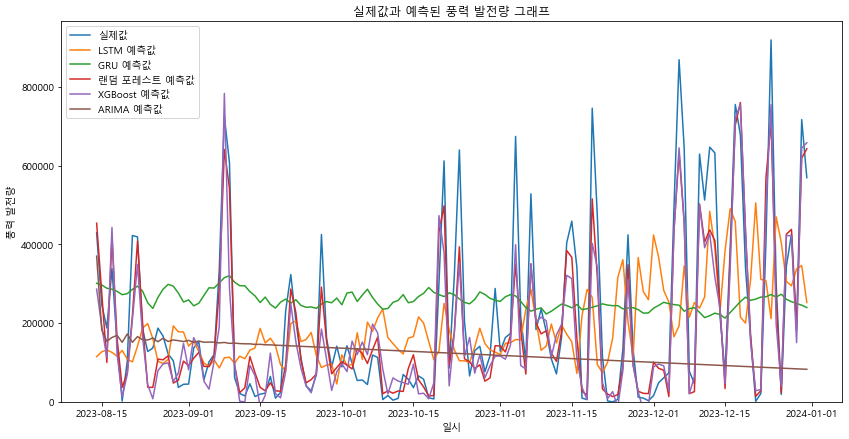

In [13]:
# 실제값과 예측값 시각화
plt.figure(figsize=(14, 7))
plt.plot(dates, y_test_inv_rf, label='실제값')
plt.plot(dates, lstm_pred_inv_seq, label='LSTM 예측값')
plt.plot(dates, gru_pred_inv_seq, label='GRU 예측값')
plt.plot(dates, rf_pred, label='랜덤 포레스트 예측값')
plt.plot(dates, xgb_pred, label='XGBoost 예측값')
plt.plot(dates, arima_pred, label='ARIMA 예측값')
plt.legend()
plt.title('실제값과 예측된 풍력 발전량 그래프')
plt.xlabel('일시')
plt.ylabel('풍력 발전량')
plt.ylim(bottom=0)  # y축의 최소값을 0으로 설정
plt.show()

In [14]:
# 성능 평가 비교 시각화
metrics = ['MSE', 'MAE', 'NMAE', 'R2']
lstm_metrics = [lstm_mse, lstm_mae, lstm_nmae, lstm_r2]
gru_metrics = [gru_mse, gru_mae, gru_nmae, gru_r2]
rf_metrics = [rf_mse, rf_mae, rf_nmae, rf_r2]
xgb_metrics = [xgb_mse, xgb_mae, xgb_nmae, xgb_r2]
arima_metrics = [arima_mse, arima_mae, arima_nmae, arima_r2]

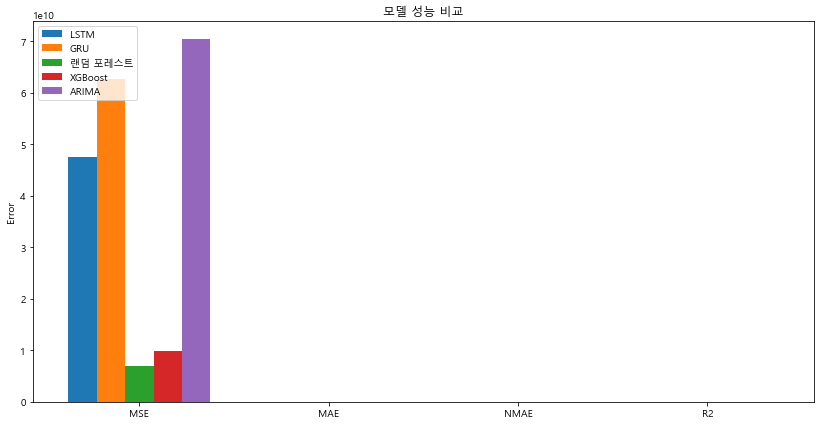

In [15]:
# 성능 평가 비교 시각화
metrics = ['MSE', 'MAE', 'NMAE', 'R2']
lstm_metrics = [lstm_mse, lstm_mae, lstm_nmae, lstm_r2]
gru_metrics = [gru_mse, gru_mae, gru_nmae, gru_r2]
rf_metrics = [rf_mse, rf_mae, rf_nmae, rf_r2]
xgb_metrics = [xgb_mse, xgb_mae, xgb_nmae, xgb_r2]
arima_metrics = [arima_mse, arima_mae, arima_nmae, arima_r2]

x = np.arange(len(metrics))
width = 0.15

fig, ax1 = plt.subplots(figsize=(14, 7))

# MSE 막대 그래프
ax1.bar(x - 2*width, lstm_metrics, width, label='LSTM')
ax1.bar(x - width, gru_metrics, width, label='GRU')
ax1.bar(x, rf_metrics, width, label='랜덤 포레스트')
ax1.bar(x + width, xgb_metrics, width, label='XGBoost')
ax1.bar(x + 2*width, arima_metrics, width, label='ARIMA')
ax1.set_ylabel('Error')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics)
ax1.legend(loc='upper left')

plt.title('모델 성능 비교')
plt.show()

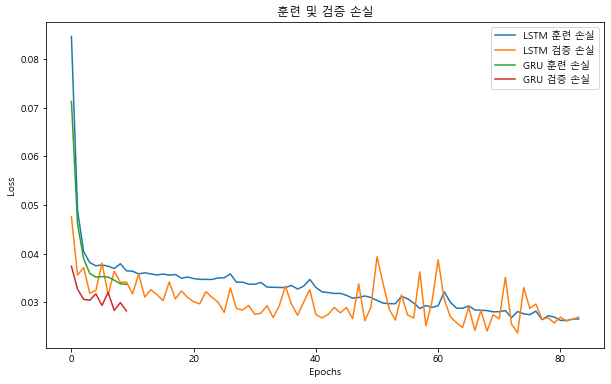

In [16]:
# 손실 그래프 시각화
plt.figure(figsize=(10, 6))
plt.plot(lstm_history.history['loss'], label='LSTM 훈련 손실')
plt.plot(lstm_history.history['val_loss'], label='LSTM 검증 손실')
plt.plot(gru_history.history['loss'], label='GRU 훈련 손실')
plt.plot(gru_history.history['val_loss'], label='GRU 검증 손실')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('훈련 및 검증 손실')
plt.legend()
plt.show()